# 1. Libraries Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

## 1.1 Plot Settings

In [2]:
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13, 'axes.labelsize': 11, 'figure.facecolor': 'white'})

# 2. Load Dataset

In [3]:
df = pd.read_csv('cardio_train.csv', sep=';')
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


# 3. Basic Data Exploration

## 3.1 First 5 Rows

In [4]:
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


## 3.2 Last 5 Rows

In [5]:
df.tail()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1
69999,99999,20540,1,170,72.0,120,80,2,1,0,0,1,0


## 3.3 Dataset Info (dtypes + non-null counts)

In [6]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

## 3.4 Statistical Summary

In [7]:
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


## 3.5 Column Names

In [8]:
df.columns

Index(['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio'],
      dtype='str')

## 3.6 Data Types

In [9]:
df.dtypes

id               int64
age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object

## 3.7 Shape 

In [10]:
df.shape

(70000, 13)

## 3.8 Total Values

In [11]:
df.size

910000

## Boxplot (Initial Outlier View)

<Axes: >

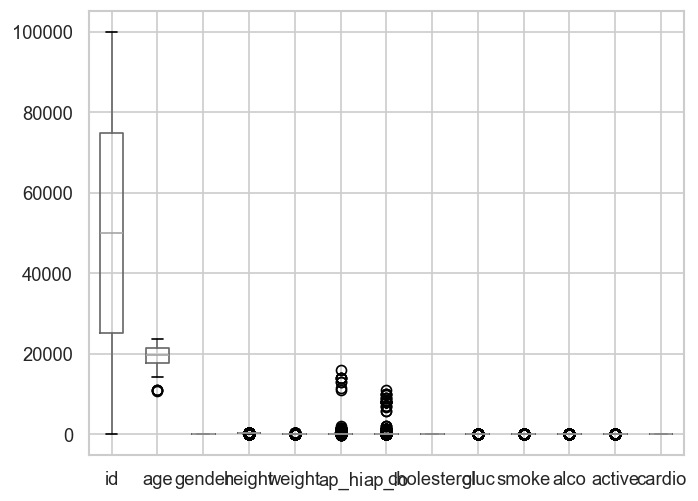

In [12]:
df.boxplot()

## 4.2 Duplicate Rows

In [13]:
df.duplicated().sum()

np.int64(0)

## 4.3 Unique Values per Column

In [14]:
df.nunique()

id             70000
age             8076
gender             2
height           109
weight           287
ap_hi            153
ap_lo            157
cholesterol        3
gluc               3
smoke              2
alco               2
active             2
cardio             2
dtype: int64

## 4.5 Outlier Detection (Blood Pressure, Height, Weight)

In [15]:
outliers = pd.Series({
    'ap_hi < 0':      (df['ap_hi'] < 0).sum(),
    'ap_hi > 300':    (df['ap_hi'] > 300).sum(),
    'ap_lo < 0':      (df['ap_lo'] < 0).sum(),
    'ap_lo > 200':    (df['ap_lo'] > 200).sum(),
    'ap_lo >= ap_hi': (df['ap_lo'] >= df['ap_hi']).sum(),
    'height < 100':   (df['height'] < 100).sum(),
    'height > 220':   (df['height'] > 220).sum(),
    'weight < 30':    (df['weight'] < 30).sum()
})
outliers

df['age'].agg(['min', 'max']) / 365

min    29.583562
max    64.967123
Name: age, dtype: float64

# 5. Data Cleaning and Feature Engineering

## 5.1 Remove Outliers and Invalid Values

In [16]:
df = df.copy()

# Age in years
df['age_years'] = (df['age'] / 365.25).round(1)

# Remove invalid blood pressure
df = df[(df['ap_hi'] >= 50) & (df['ap_hi'] <= 300)]
df = df[(df['ap_lo'] >= 30) & (df['ap_lo'] <= 200)]
df = df[df['ap_lo'] < df['ap_hi']]

# Remove unrealistic height and weight
df = df[(df['height'] >= 100) & (df['height'] <= 220)]
df = df[df['weight'] >= 30]

print(f"Rows after cleaning: {df.shape[0]}")

Rows after cleaning: 68645


## 5.2 Feature Engineering  (BMI and Age Groups)

In [17]:
# BMI
df['bmi'] = (df['weight'] / (df['height'] / 100) ** 2).round(2)

def bmi_category(bmi):
    if bmi < 18.5: return 'Underweight'
    elif bmi < 25: return 'Normal'
    elif bmi < 30: return 'Overweight'
    else:          return 'Obese'

df['bmi_category'] = df['bmi'].apply(bmi_category)

def age_group(age):
    if age < 40:   return '30-39'
    elif age < 50: return '40-49'
    elif age < 60: return '50-59'
    else:          return '60+'

df['age_group'] = df['age_years'].apply(age_group)

## 5.3 Encoding 

In [18]:
df['gender_label']      = df['gender'].map({1: 'Female', 2: 'Male'})
df['cholesterol_label'] = df['cholesterol'].map({1: 'Normal', 2: 'Above Normal', 3: 'Well Above Normal'})
df['gluc_label']        = df['gluc'].map({1: 'Normal', 2: 'Above Normal', 3: 'Well Above Normal'})
df['cardio_label']      = df['cardio'].map({0: 'No Disease', 1: 'Has Disease'})

df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,...,active,cardio,age_years,bmi,bmi_category,age_group,gender_label,cholesterol_label,gluc_label,cardio_label
0,0,18393,2,168,62.0,110,80,1,1,0,...,1,0,50.4,21.97,Normal,50-59,Male,Normal,Normal,No Disease
1,1,20228,1,156,85.0,140,90,3,1,0,...,1,1,55.4,34.93,Obese,50-59,Female,Well Above Normal,Normal,Has Disease
2,2,18857,1,165,64.0,130,70,3,1,0,...,0,1,51.6,23.51,Normal,50-59,Female,Well Above Normal,Normal,Has Disease
3,3,17623,2,169,82.0,150,100,1,1,0,...,1,1,48.2,28.71,Overweight,40-49,Male,Normal,Normal,Has Disease
4,4,17474,1,156,56.0,100,60,1,1,0,...,0,0,47.8,23.01,Normal,40-49,Female,Normal,Normal,No Disease


# 6. Univariate Analysis

## 6.1 Age Distribution

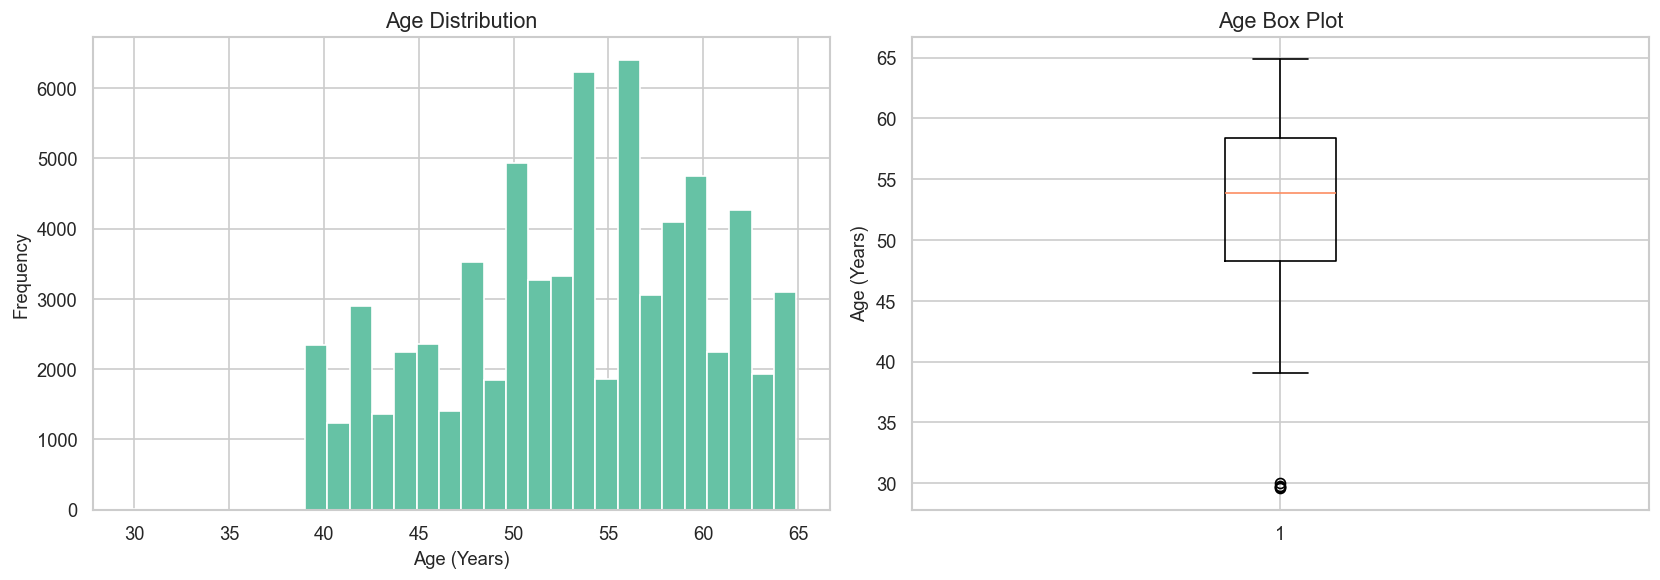

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['age_years'], bins=30)
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age (Years)')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(df['age_years'])
axes[1].set_title('Age Box Plot')
axes[1].set_ylabel('Age (Years)')

plt.tight_layout()
plt.show()

## 6.2 Age Summary Stats

In [20]:
df['age_years'].describe()

count    68645.000000
mean        53.291506
std          6.757279
min         29.600000
25%         48.300000
50%         53.900000
75%         58.400000
max         64.900000
Name: age_years, dtype: float64

## 6.3 Blood Pressure Distribution

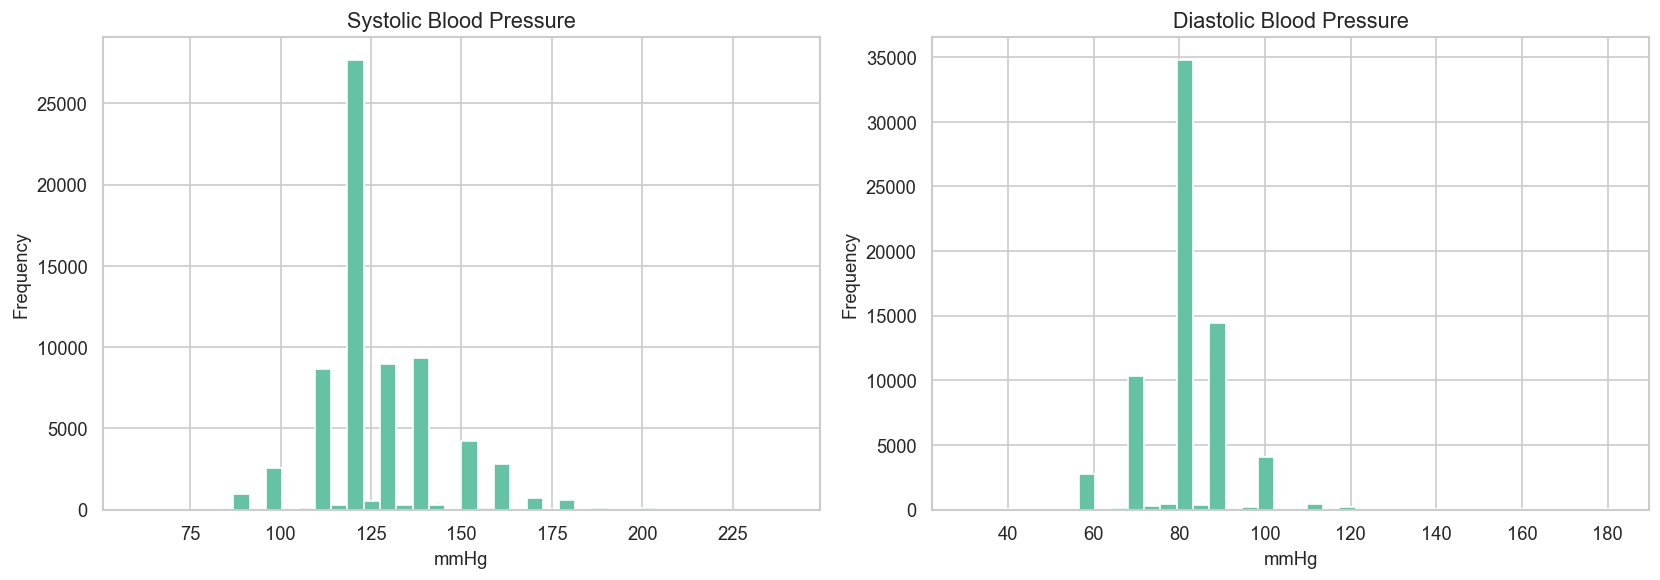

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['ap_hi'], bins=40)
axes[0].set_title('Systolic Blood Pressure')
axes[0].set_xlabel('mmHg')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['ap_lo'], bins=40)
axes[1].set_title('Diastolic Blood Pressure')
axes[1].set_xlabel('mmHg')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 6.4 Blood Pressure Summary

In [22]:
df[['ap_hi', 'ap_lo']].describe()

,ap_hi,ap_lo
count,68645.000000,68645.000000
mean,126.676247,81.303125
std,16.695585,9.466243
min,60.000000,30.000000
25%,120.000000,80.000000
50%,120.000000,80.000000
75%,140.000000,90.000000
max,240.000000,182.000000


## 6.5 BMI Distribution & Categories

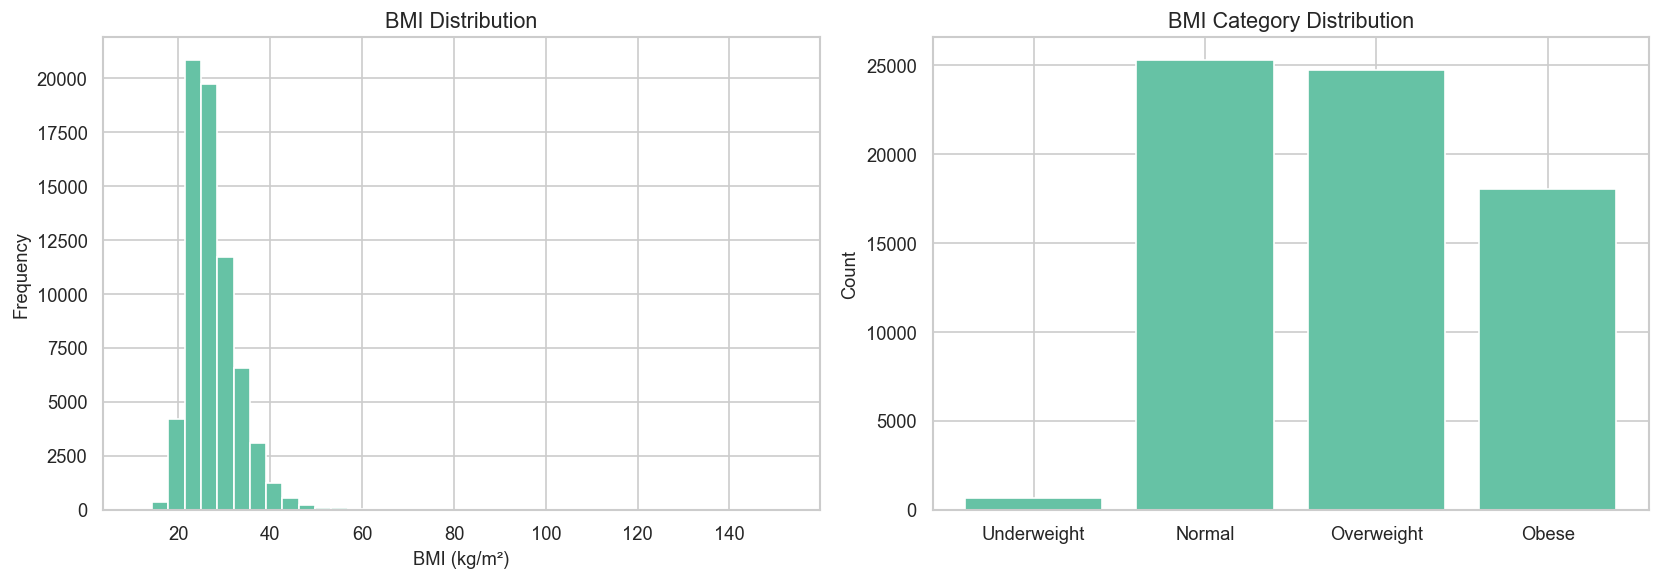

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['bmi'], bins=40)
axes[0].set_title('BMI Distribution')
axes[0].set_xlabel('BMI (kg/m²)')
axes[0].set_ylabel('Frequency')

cat_order  = ['Underweight', 'Normal', 'Overweight', 'Obese']
cat_counts = df['bmi_category'].value_counts().reindex(cat_order)
axes[1].bar(cat_counts.index, cat_counts.values)
axes[1].set_title('BMI Category Distribution')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 6.6 BMI Category Counts & Percentages

In [24]:
df['bmi_category'].value_counts()

bmi_category
Normal         25295
Overweight     24714
Obese          18006
Underweight      630
Name: count, dtype: int64

In [25]:
df['bmi_category'].value_counts(normalize=True) * 100

bmi_category
Normal         36.849006
Overweight     36.002622
Obese          26.230607
Underweight     0.917765
Name: proportion, dtype: float64

## 6.7 Categorical Variables Distribution

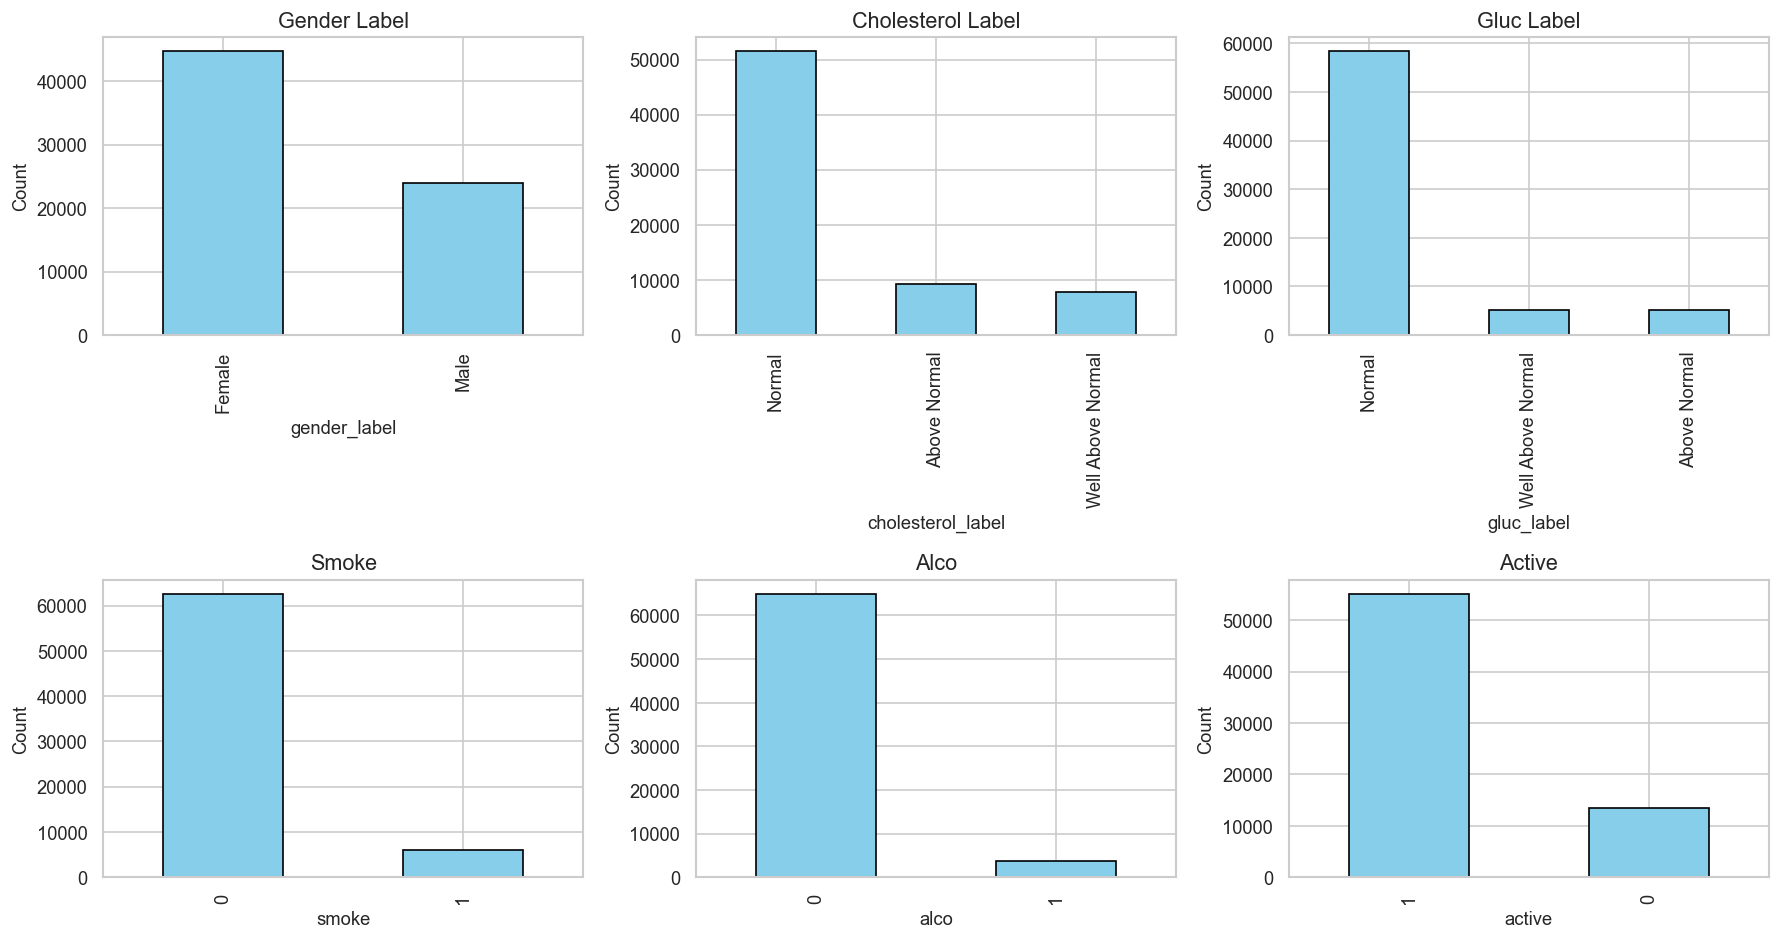

In [26]:
cat_vars = ['gender_label', 'cholesterol_label', 'gluc_label', 'smoke', 'alco', 'active']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, cat_vars):
    df[col].value_counts().plot(kind='bar', ax=ax, color='skyblue', edgecolor='black')
    ax.set_title(col.replace('_', ' ').title())
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

## 6.8 Target Variable (Cardiovascular Disease) Distribution

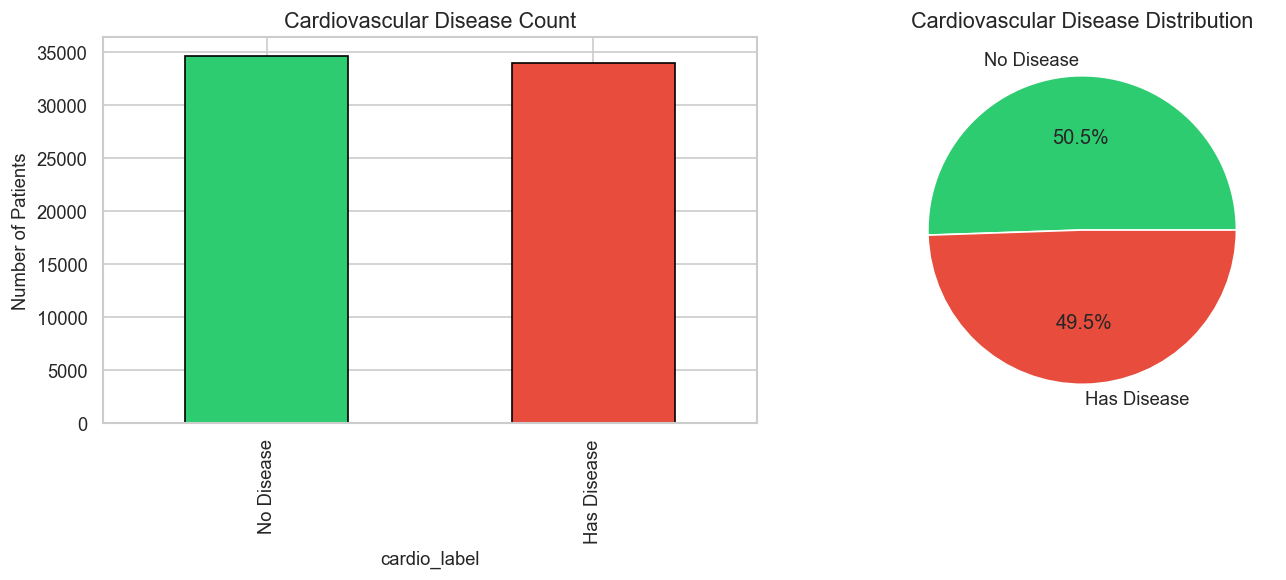

In [27]:
counts = df['cardio_label'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Cardiovascular Disease Count')
axes[0].set_ylabel('Number of Patients')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'])
axes[1].set_title('Cardiovascular Disease Distribution')

plt.tight_layout()
plt.show()

## 6.9 Patient Count by Age Group

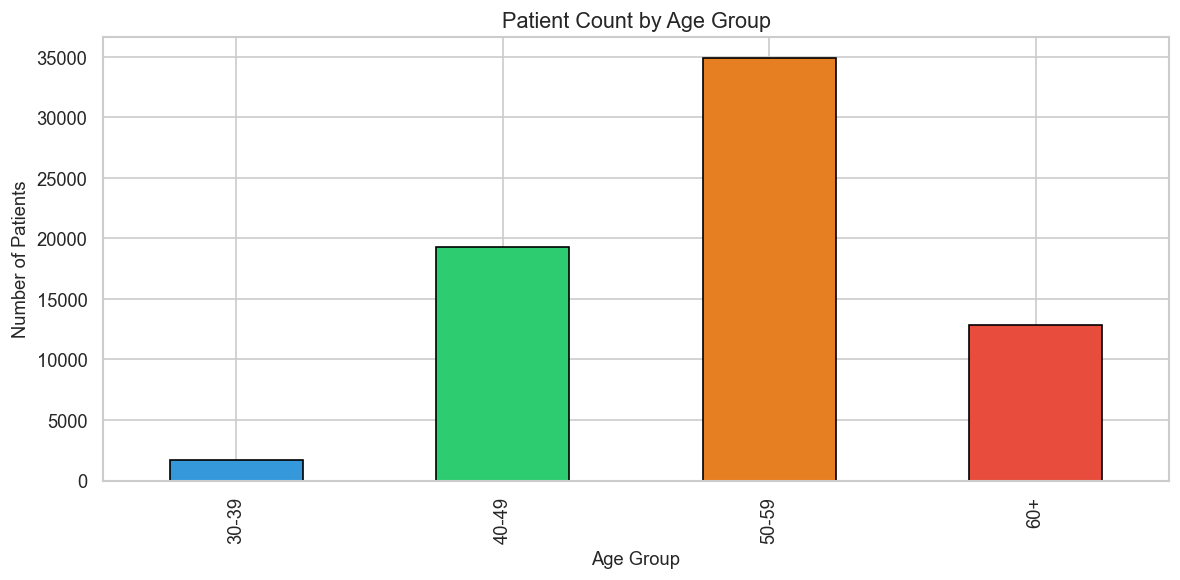

In [28]:
order  = ['30-39', '40-49', '50-59', '60+']
counts = df['age_group'].value_counts().reindex(order)

counts.plot(kind='bar', color=['#3498db', '#2ecc71', '#e67e22', '#e74c3c'], edgecolor='black', figsize=(10, 5))
plt.title('Patient Count by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

# 7. Bivariate and Multivariate Analysis

## 7.1 Correlation Heatmap

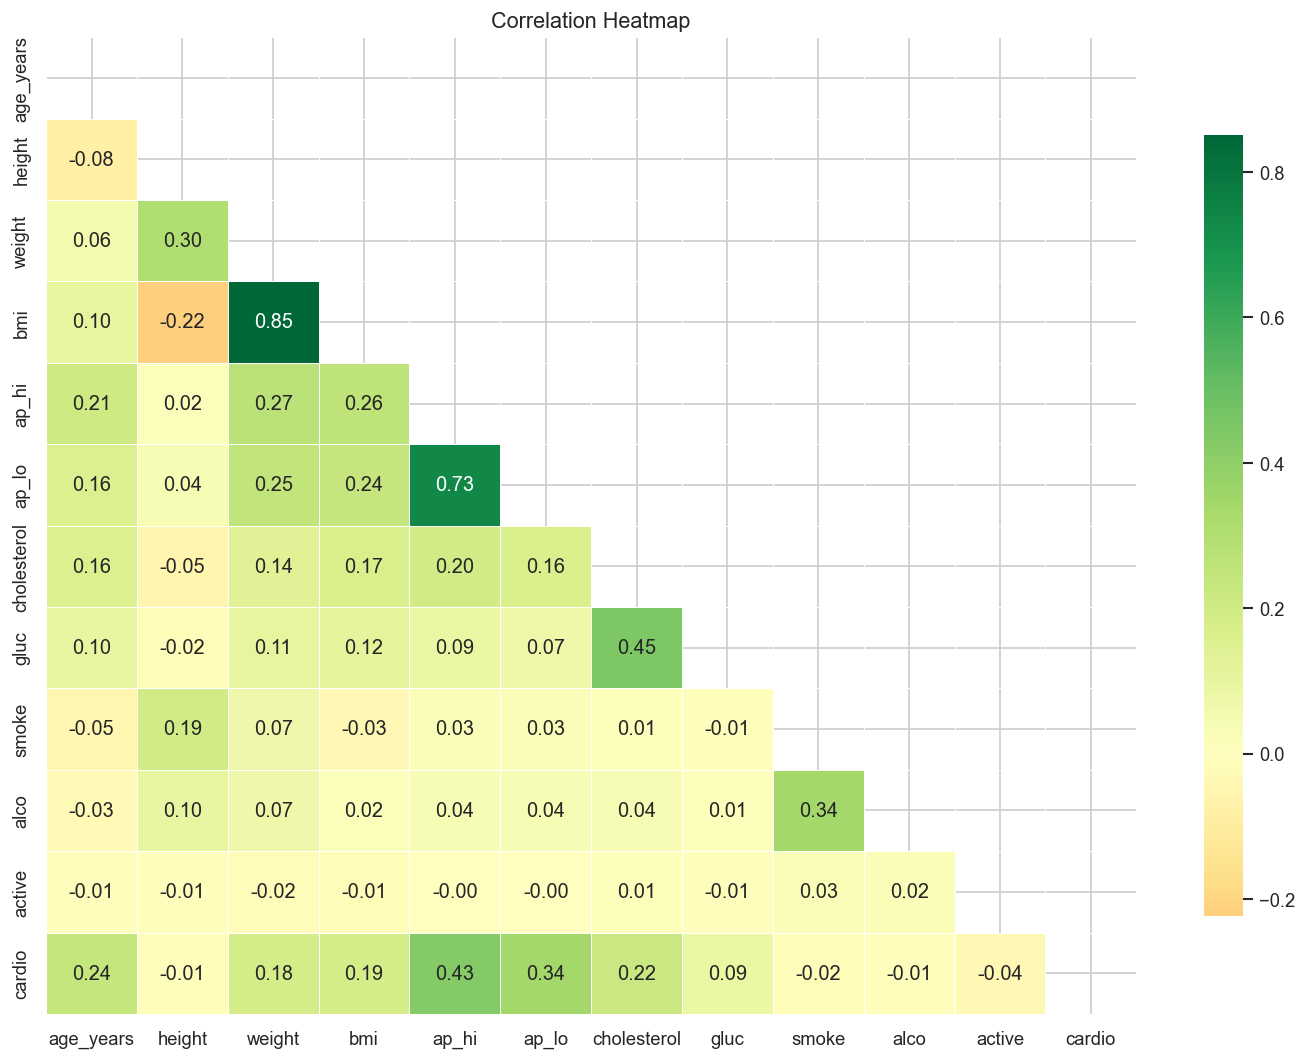

In [29]:
numeric_cols = ['age_years', 'height', 'weight', 'bmi', 'ap_hi', 'ap_lo',
                'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']

corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            mask=mask, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## 7.2 Cardiovascular Disease by Age Group

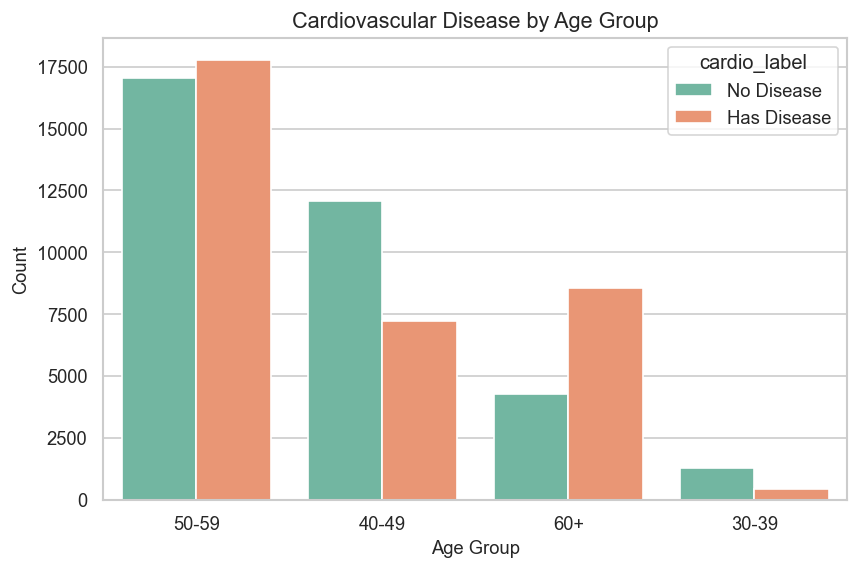

In [30]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='age_group', hue='cardio_label')
plt.title('Cardiovascular Disease by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.show()

## 7.3 Cardiovascular Disease by BMI Category

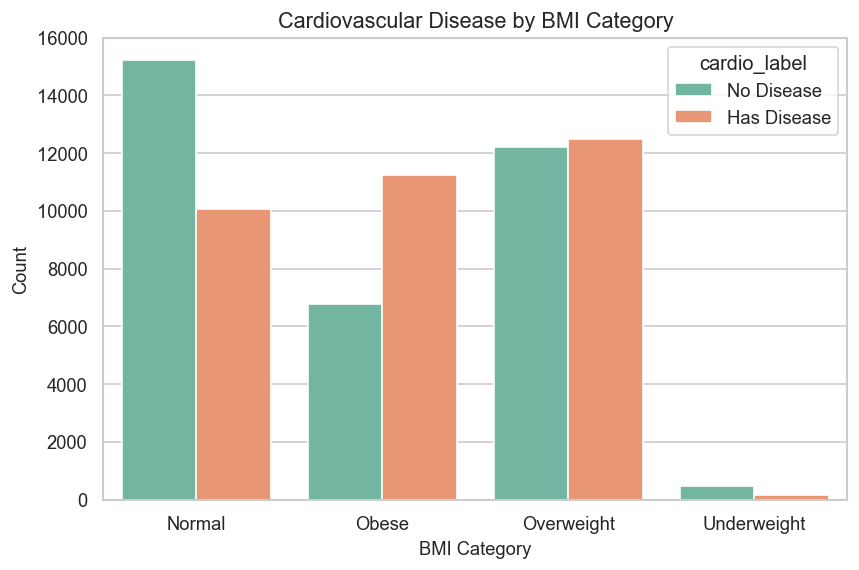

In [31]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='bmi_category', hue='cardio_label')
plt.title('Cardiovascular Disease by BMI Category')
plt.xlabel('BMI Category')
plt.ylabel('Count')
plt.show()

## 7.4 Cardiovascular Disease by Cholesterol Level

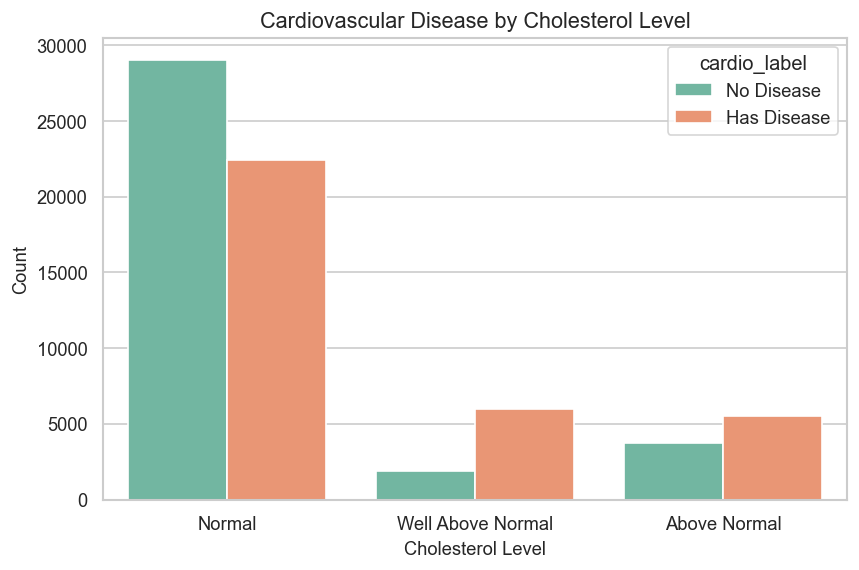

In [32]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='cholesterol_label', hue='cardio_label')
plt.title('Cardiovascular Disease by Cholesterol Level')
plt.xlabel('Cholesterol Level')
plt.ylabel('Count')
plt.show()

## 7.5 Age vs BMI by Disease Status

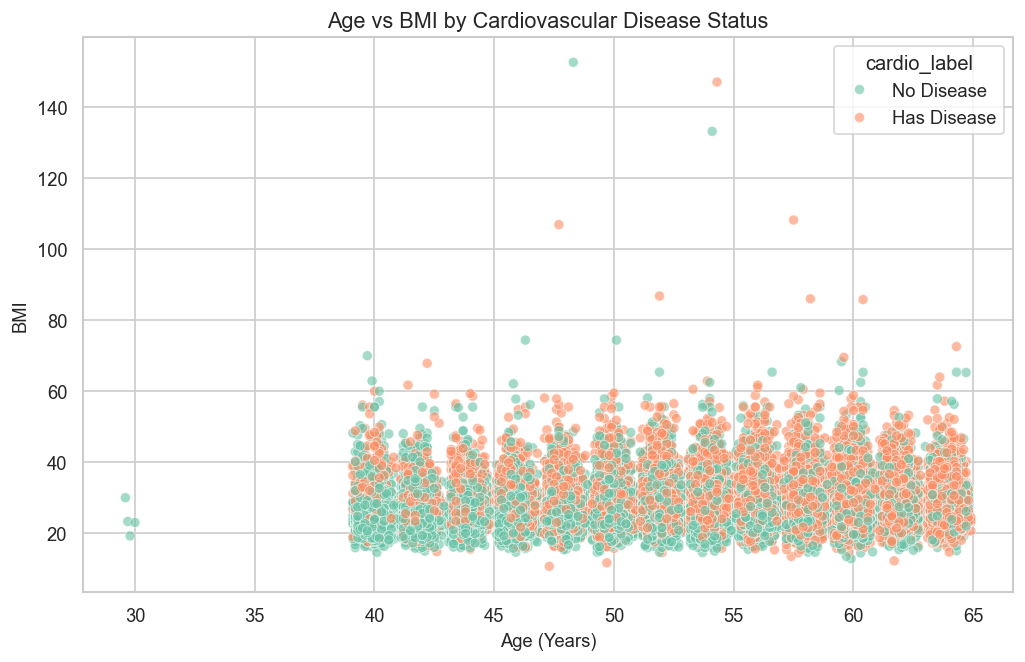

In [33]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='age_years', y='bmi', hue='cardio_label', alpha=0.6)
plt.title('Age vs BMI by Cardiovascular Disease Status')
plt.xlabel('Age (Years)')
plt.ylabel('BMI')
plt.show()

## 7.6 Systolic vs Diastolic BP by Disease Status

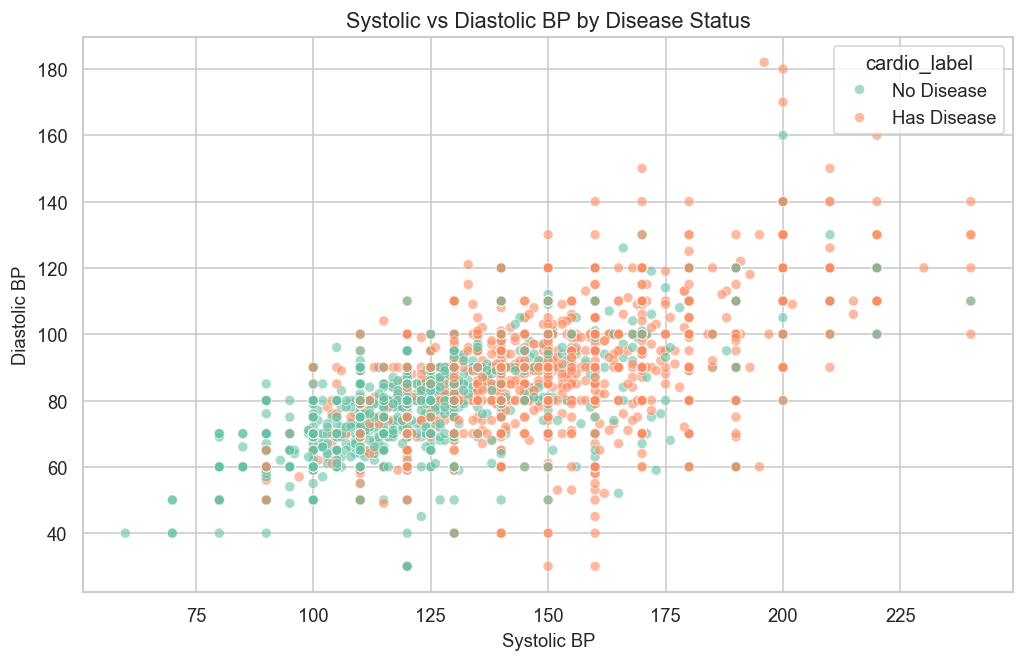

In [34]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='ap_hi', y='ap_lo', hue='cardio_label', alpha=0.6)
plt.title('Systolic vs Diastolic BP by Disease Status')
plt.xlabel('Systolic BP')
plt.ylabel('Diastolic BP')
plt.show()

# 8. Export Cleaned Dataset

In [35]:
df.to_csv('cardio_cleaned.csv', index=False)
print("Cleaned dataset exported successfully!")
print(f"Shape: {df.shape}")

Cleaned dataset exported successfully!
Shape: (68645, 21)
